<a href="https://colab.research.google.com/github/Andalejo1109/Gold-trading-bot-vs-long-term-investing/blob/main/bot_trading_15min.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas_ta

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 14.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstal

In [ ]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import matplotlib.pyplot as plt
import numpy as np


In [ ]:

# 1. Parámetros del Backtest
TICKER = "GC=F"  # Futuros del Oro en Yahoo Finance (referencia más cercana a XAUUSD)
PERIODO = "60d"  # Máximo permitido por yfinance para datos intradiarios
INTERVALO = "15m"
COSTO_TRANSACCION = 0.00015  # Simulación de spread/comisiones (0.015% por trade)

print(f"Descargando datos de {TICKER} a {INTERVALO}...")
df = yf.download(TICKER, period=PERIODO, interval=INTERVALO, progress=False)

if df.empty:
    print("Error descargando datos.")
    quit()

# Aplanar columnas si yfinance devuelve un MultiIndex
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)



Descargando datos de GC=F a 15m...


/tmp/ipykernel_2646/3199288413.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, period=PERIODO, interval=INTERVALO, progress=False)


In [ ]:
# 2. Cálculo de Indicadores
df.ta.ema(close='Close', length=9, append=True)
df.ta.ema(close='Close', length=21, append=True)
df.rename(columns={'EMA_9': 'ema_9', 'EMA_21': 'ema_21'}, inplace=True)
df.dropna(inplace=True)

# 3. Lógica Vectorizada de Señales (1 = Largo, -1 = Corto)
# Generamos la señal evaluando si la EMA 9 está por encima de la EMA 21
df['signal'] = np.where(df['ema_9'] > df['ema_21'], 1, -1)

# Desplazamos la señal un período (shift(1)) porque operamos en la apertura de la SIGUIENTE vela tras el cruce
df['position'] = df['signal'].shift(1)
df.dropna(inplace=True)

# 4. Cálculo de Rendimientos
# Rendimiento natural del activo (Buy & Hold)
df['returns_bh'] = df['Close'].pct_change()

# Rendimiento de la estrategia (Rendimiento del activo * Posición)
df['returns_strategy'] = df['returns_bh'] * df['position']

# 5. Aplicar Costos de Transacción
# Cada vez que la posición cambia (de 1 a -1 o viceversa), restamos el costo del spread
df['trade'] = df['position'].diff().abs() > 0
df.loc[df['trade'], 'returns_strategy'] -= COSTO_TRANSACCION

# 6. Calcular Curvas de Crecimiento (Capitalizando los retornos diarios)
df['equity_bh'] = (1 + df['returns_bh']).cumprod() * 1000
df['equity_strategy'] = (1 + df['returns_strategy']).cumprod() * 1000

# 7. Métricas de Rendimiento
total_trades = df['trade'].sum()
rendimiento_bh = (df['equity_bh'].iloc[-1] / 1000 - 1) * 100
rendimiento_estrategia = (df['equity_strategy'].iloc[-1] / 1000 - 1) * 100
win_rate = (df.loc[df['trade'], 'returns_strategy'] > 0).mean() * 100

print("-" * 40)
print(f"📊 RESULTADOS DEL BACKTEST ({PERIODO} en {INTERVALO})")
print("-" * 40)
print(f"Operaciones ejecutadas : {total_trades}")
print(f"Rendimiento Buy & Hold : {rendimiento_bh:.2f}%")
print(f"Rendimiento del Bot    : {rendimiento_estrategia:.2f}%")
print(f"Win Rate estimado      : {win_rate:.2f}%")
print("-" * 40)



----------------------------------------
📊 RESULTADOS DEL BACKTEST (60d en 15m)
----------------------------------------
Operaciones ejecutadas : 199
Rendimiento Buy & Hold : -1.17%
Rendimiento del Bot    : 3.57%
Win Rate estimado      : 43.22%
----------------------------------------


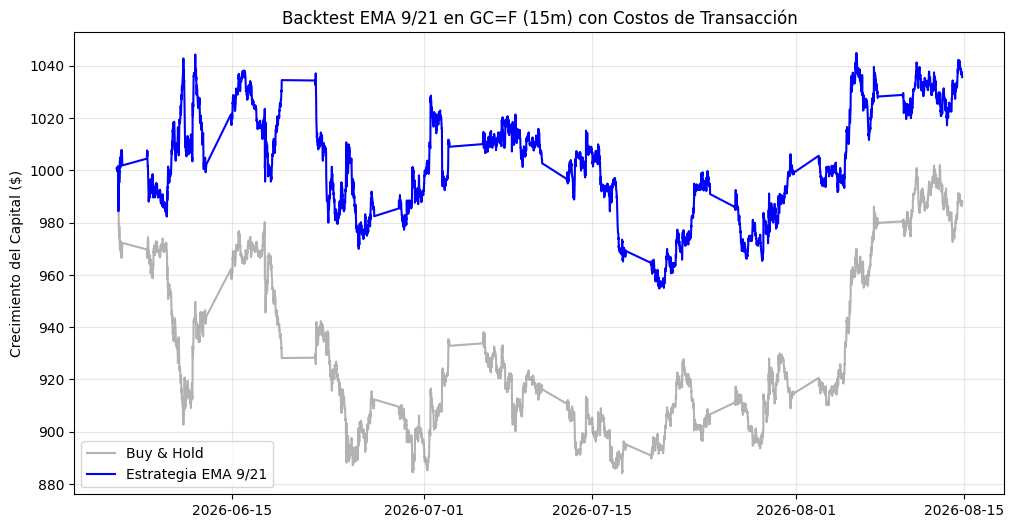

In [ ]:
# 8. Visualización
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['equity_bh'], label='Buy & Hold', color='gray', alpha=0.6)
plt.plot(df.index, df['equity_strategy'], label='Estrategia EMA 9/21', color='blue')
plt.title(f'Backtest EMA 9/21 en {TICKER} ({INTERVALO}) con Costos de Transacción')
plt.ylabel('Crecimiento del Capital ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()